In [3]:
# Import Required Libaries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot Settings
plt.style.use("default")
sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [4]:
# 2) Load Clean Dataset

df = pd.read_csv("used_cars_clean.csv")

print("Dataset Loaded Successfully")

print(f"Shape : {df.shape}")

display(df.head())

Dataset Loaded Successfully
Shape : (13982, 14)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,Posted_Year,Posted_Month,Posted_Month_Name
0,Honda,City,2001,23,98000.0,Manual,second,Petrol,2024-11-01,"Honda City v teck in mint condition, valid gen...",195000,2024,11,November
1,Toyota,Innova,2009,15,190000.0,Manual,second,Diesel,2024-07-01,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000,2024,7,July
2,Volkswagen,VentoTest,2010,14,77246.0,Manual,first,Diesel,2024-11-01,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999,2024,11,November
3,Maruti Suzuki,Swift,2017,7,83500.0,Manual,second,Diesel,2024-11-01,Maruti Suzuki Swift 2017 Diesel Good Condition,565000,2024,11,November
4,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,first,Petrol,2024-11-01,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000,2024,11,November


In [5]:
# 3) Basic Dataset Overview

print("Dataset Overview")
print("-" * 70)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nNumerical Features")
display(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Features")
display(df.select_dtypes(include="object").columns.tolist())

Dataset Overview
----------------------------------------------------------------------
Rows    : 13982
Columns : 14

Numerical Features


['Year', 'Age', 'kmDriven', 'AskPrice', 'Posted_Year', 'Posted_Month']


Categorical Features


['Brand',
 'model',
 'Transmission',
 'Owner',
 'FuelType',
 'PostedDate',
 'AdditionInfo',
 'Posted_Month_Name']

## Part 1: Target Variable Analysis

In [6]:
# Target Variable Summary

print("AskPrice Summary Statistics:")
print("-"*60)

print(df["AskPrice"].describe())

print("\n")

print(f"Skewness : {df['AskPrice'].skew():.2f}")
print(f"Kurtosis : {df['AskPrice'].kurtosis():.2f}")

AskPrice Summary Statistics:
------------------------------------------------------------
count    1.398200e+04
mean     9.798977e+05
std      1.586180e+06
min      1.500000e+04
25%      3.400000e+05
50%      5.600000e+05
75%      9.900000e+05
max      4.250000e+07
Name: AskPrice, dtype: float64


Skewness : 8.41
Kurtosis : 127.05


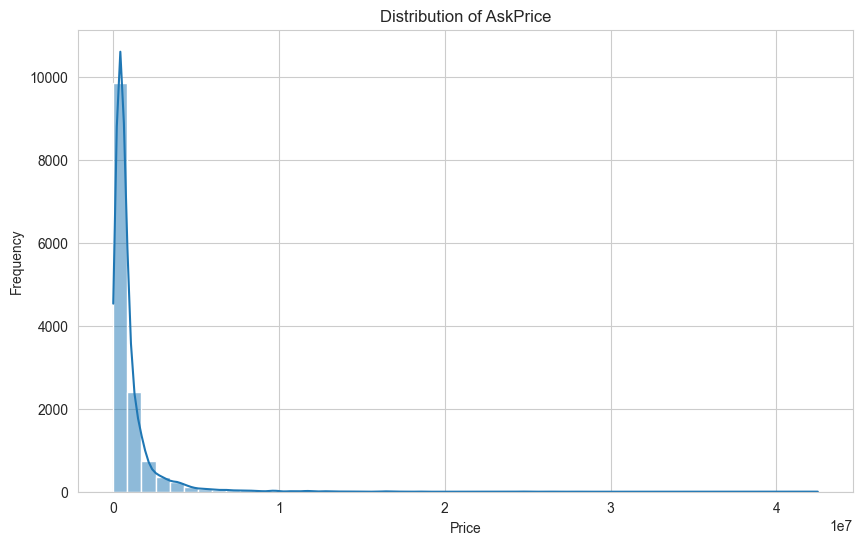

In [7]:
# Graph 1: Histogram with KDE

sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(
    df["AskPrice"],
    bins=50,
    kde=True
)

plt.title("Distribution of AskPrice")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

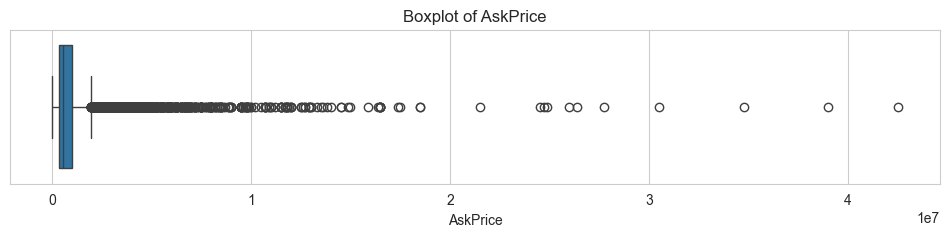

In [8]:
# Graph 2: Boxplot of AskPrice

plt.figure(figsize=(12,2))

sns.boxplot(
    x=df["AskPrice"]
)

plt.title("Boxplot of AskPrice")

plt.show()

In [34]:
# Percentiles

percentiles = df["AskPrice"].quantile([
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

print(percentiles)

0.01      79809.19
0.05     148000.00
0.25     340000.00
0.50     560000.00
0.75     990000.00
0.90    1950000.00
0.95    3200000.00
0.99    7495760.00
Name: AskPrice, dtype: float64


**Interpretation:** 
- The target variable **(AskPrice)** is **highly positively (right) skewed**, meaning most used cars are listed in the low to mid-price range, while only a small proportion belong to the **premium/luxury segment**. The mean price **(₹979,897)** is much higher than the median **(₹560,000)**, indicating that expensive vehicles significantly influence the average.

- The histogram and boxplot show that most cars are priced below **₹10 lakh**, with numerous genuine high-value outliers reaching **₹4.25 crore**. The **skewness (8.41)** and **kurtosis (127.05)** confirm an extremely right-skewed, heavy-tailed distribution. Additionally, **75% of vehicles are priced below ₹9.90 lakh**, while the **top 1% exceed ₹74.95 lakh**, reflecting the presence of a small luxury vehicle market.

Overall, these outliers represent **real market characteristics** rather than data quality issues and should not be removed without proper justification.


**Business Recommendation:**
- The used car market consists of **multiple pricing segments**, so dealerships and online marketplaces should adopt **segment-specific pricing strategies** for affordable and luxury vehicles.

- From a machine learning perspective, the highly skewed target distribution can reduce regression model performance. Applying a **logarithmic transformation (log1p)** to **AskPrice** during training can reduce skewness, stabilize variance, and improve prediction accuracy. The predicted values can then be converted back to the original price scale using expm1 during deployment.

## Part 2: Numerical Feature Analysis

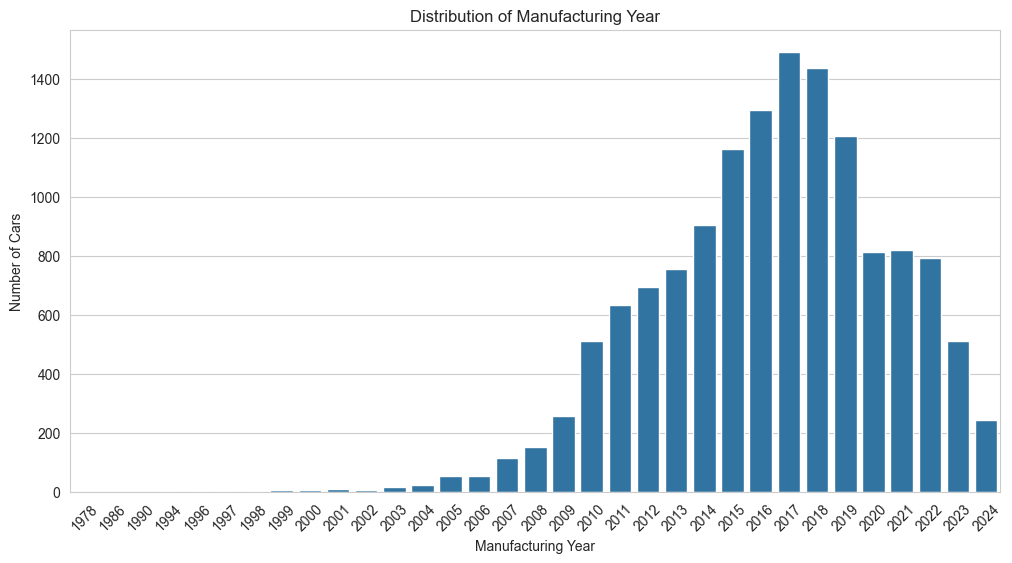

In [10]:
# Graph 3: Manufacturing Year Distribution

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Year",
    order=sorted(df["Year"].unique())
)

plt.title("Distribution of Manufacturing Year")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

In [11]:
# Year Summary Statistics
print(df["Year"].describe())

count    13982.000000
mean      2016.349807
std          4.142067
min       1978.000000
25%       2014.000000
50%       2017.000000
75%       2019.000000
max       2024.000000
Name: Year, dtype: float64


In [12]:
# Top Manufacturing Years

year_counts = (
    df["Year"]
    .value_counts()
    .sort_index()
)

year_counts

Year
1978       1
1986       1
1990       1
1994       3
1996       2
1997       2
1998       3
1999       5
2000       6
2001       9
2002       8
2003      18
2004      25
2005      55
2006      55
2007     116
2008     152
2009     256
2010     510
2011     635
2012     694
2013     754
2014     906
2015    1162
2016    1293
2017    1491
2018    1435
2019    1205
2020     813
2021     821
2022     792
2023     510
2024     243
Name: count, dtype: int64

**Observation:**
- The distribution of manufacturing years shows that the dataset is dominated by **recently manufactured vehicles**, with the highest concentration between **2015 and 2019**. The peak occurs in **2017 (1,491 cars)**, followed closely by **2018 (1,435 cars)** and **2016 (1,293 cars)**. In contrast, vehicles manufactured before **2010** constitute only a small portion of the dataset, while listings for classic vehicles (before 2000) are extremely rare.

**Interpretation:**
- The manufacturing year distribution shows that the used car market is dominated by **relatively modern vehicles**. **The average manufacturing year is 2016 and the median is 2017**, indicating that most listed cars are around **7–10 years old**, which aligns with typical resale cycles.

- Listings increase steadily from **2010 to 2017**, reflecting higher availability of newer pre-owned vehicles, while listings decline **after 2019** since newer cars have had less time to enter the resale market. Vehicles manufactured **before 2000** are rare, representing a small niche of classic or vintage cars.

- Overall, the dataset provides a strong representation of modern used vehicles, making it well-suited for analyzing **vehicle depreciation** and **price prediction**.

**Business Recommendation:**
- Dealerships and online marketplaces should focus on vehicles manufactured between **2015 and 2019**, as they balance **affordability, modern features**, and **remaining lifespan**, making them highly attractive to buyers.

- From a machine learning perspective, **Manufacturing Year** is a key predictor of resale value because newer vehicles generally depreciate less and command higher prices. It should therefore be retained as an important feature in the price prediction model.

## Part 3 – Numerical Feature Analysis (Kilometers Driven)

In [13]:
# kmDriven Summary Statistics

print("Kilometers Driven Summary Statistics")
print("-"*40)

print(df["kmDriven"].describe())

print("\n")

print(f"Skewness : {df['kmDriven'].skew():.2f}")
print(f"Kurtosis : {df['kmDriven'].kurtosis():.2f}")

Kilometers Driven Summary Statistics
----------------------------------------
count     13895.000000
mean      71513.959914
std       58348.761488
min           0.000000
25%       44000.000000
50%       66000.000000
75%       87000.000000
max      980002.000000
Name: kmDriven, dtype: float64


Skewness : 6.86
Kurtosis : 79.20


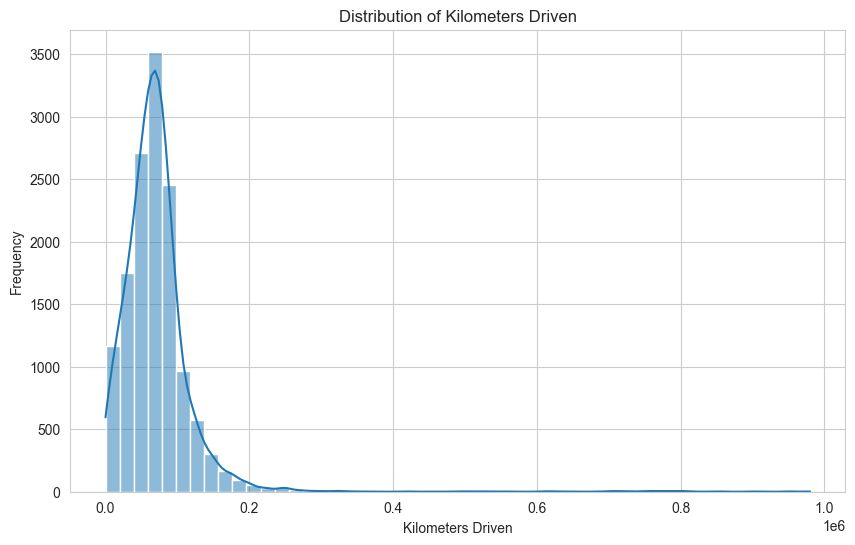

In [14]:
# Graph 4: Distribution Plot

plt.figure(figsize=(10,6))

sns.histplot(
    df["kmDriven"],
    bins=50,
    kde=True
)

plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Frequency")

plt.show()

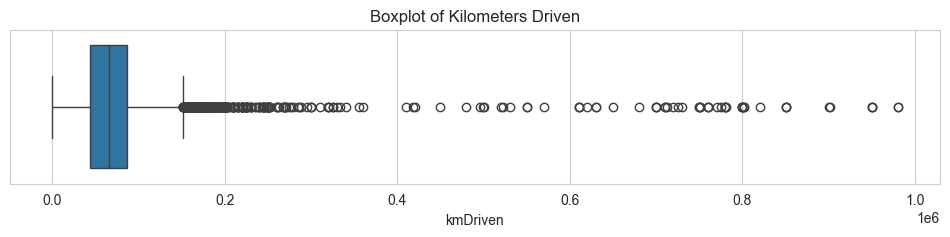

In [15]:
# Graph 5: Boxplot

plt.figure(figsize=(12,2))

sns.boxplot(
    x=df["kmDriven"]
)

plt.title("Boxplot of Kilometers Driven")

plt.show()

In [16]:
# Percentiles

percentiles = df["kmDriven"].quantile([
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

print(percentiles)

0.01        32.0
0.05     12000.0
0.25     44000.0
0.50     66000.0
0.75     87000.0
0.90    115034.6
0.95    141000.0
0.99    225000.0
Name: kmDriven, dtype: float64


**Interpretation:**
- The Kilometers Driven feature exhibits a highly positive (right) skew, with a **mean mileage of 71,513 km** and a **median of 66,000 km**, indicating that a relatively small number of high-mileage vehicles increase the overall average. The histogram confirms that most listed cars have accumulated moderate mileage, while the long right tail represents vehicles with exceptionally high usage. The boxplot further highlights numerous genuine high-mileage outliers, with values reaching **980,002 km**. The **high skewness (6.86)** and **kurtosis (79.20)** confirm an extremely right-skewed, heavy-tailed distribution. Additionally, **75%** of vehicles have been driven less than **87,000 km**, while only **1% exceed 225,000 km**, demonstrating that extremely high-mileage vehicles constitute only a small segment of the used car market.

**Business Recommendation:**
- Mileage is one of the most important determinants of a used car's resale value, as buyers generally associate lower mileage with better vehicle condition, lower maintenance costs, and a longer remaining lifespan. Therefore, dealerships and online marketplaces should prominently highlight low-mileage vehicles while pricing high-mileage vehicles more competitively to match buyer expectations. From a machine learning perspective, Kilometers Driven should be retained as a key predictive feature because it is expected to have a strong negative influence on resale price. Given its highly skewed distribution, a log1p transformation may be considered during model development if it improves model performance while preserving the underlying business relationship.

## Part 4 — Categorical Feature Analysis

In [17]:
# Owner Distribution
print("Owner Distribution:")
print("-" * 30)
print(df["Owner"].value_counts())

# Fuel Type Distribution
print("\n Fuel Type Distribution:")
print("-" * 30)
print(df["FuelType"].value_counts())


# Brand Distribution
print("\n Brand Distribution:") 
print("-" * 30)
print(df["Brand"].value_counts())

Owner Distribution:
------------------------------
Owner
second    7143
first     6839
Name: count, dtype: int64

 Fuel Type Distribution:
------------------------------
FuelType
Petrol        5394
Diesel        4841
Hybrid        1929
Hybrid/CNG    1818
Name: count, dtype: int64

 Brand Distribution:
------------------------------
Brand
Maruti Suzuki    4396
Hyundai          2320
Honda            1190
Toyota           1046
Mahindra          717
Tata              574
Mercedes-Benz     534
Volkswagen        446
BMW               378
Ford              373
Renault           355
Audi              282
Skoda             266
Kia               210
Chevrolet         126
Nissan            112
MG                108
Land Rover         97
Jeep               97
Volvo              64
Datsun             49
Jaguar             47
Mini               40
Lexus              28
Fiat               28
Porsche            27
Mitsubishi         22
Isuzu              13
Force               7
Ssangyong           5


FuelType
Petrol        5394
Diesel        4841
Hybrid        1929
Hybrid/CNG    1818
Name: count, dtype: int64


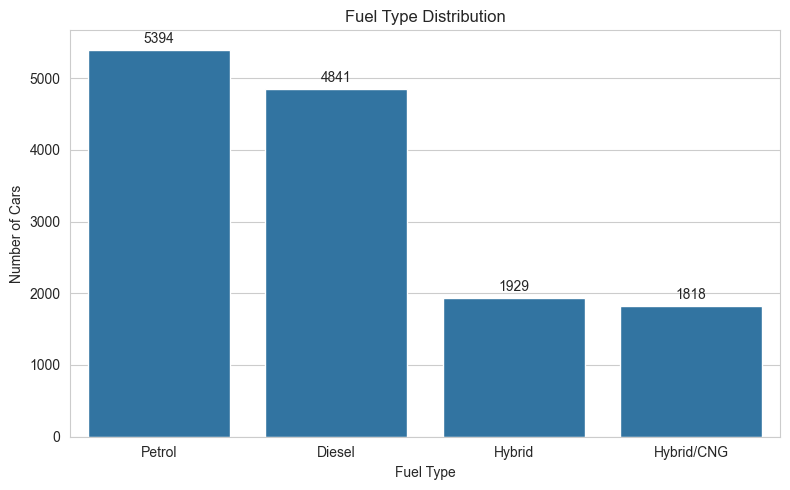

In [18]:
# Graph 6: Fuel Type Distribution

# Display frequency table
print(df["FuelType"].value_counts())

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="FuelType",
    order=df["FuelType"].value_counts().index
)

# Add count labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

**Interpretation:**
- The categorical distributions indicate that the dataset closely reflects the Indian used car market, where **Petrol** and **Diesel** vehicles dominate, while hybrid variants are still comparatively less common. The nearly balanced distribution between first-owner and second-owner vehicles provides good representation of typical resale scenarios. Additionally, the strong presence of mass-market manufacturers such as **Maruti Suzuki, Hyundai, Honda, and Toyota** suggests that the dataset primarily consists of affordable and mid-range vehicles, while premium brands represent only a small fraction of listings. Overall, the dataset captures a realistic mix of vehicle brands, fuel types, and ownership histories, making it suitable for building a robust price prediction model.

**Business Recommendation:**
- Dealerships and online marketplaces should prioritize inventory and pricing strategies around **high-demand brands and conventional fuel types**, as these represent the largest share of the used car market. At the same time, premium brands and hybrid vehicles may require specialized pricing strategies due to their lower availability and different customer segments. From a machine learning perspective, Brand, Fuel Type, and Owner should all be retained as important categorical features, as each is expected to influence vehicle resale prices and improve prediction accuracy after appropriate encoding.

##  Part 5 — Feature vs Target Analysis

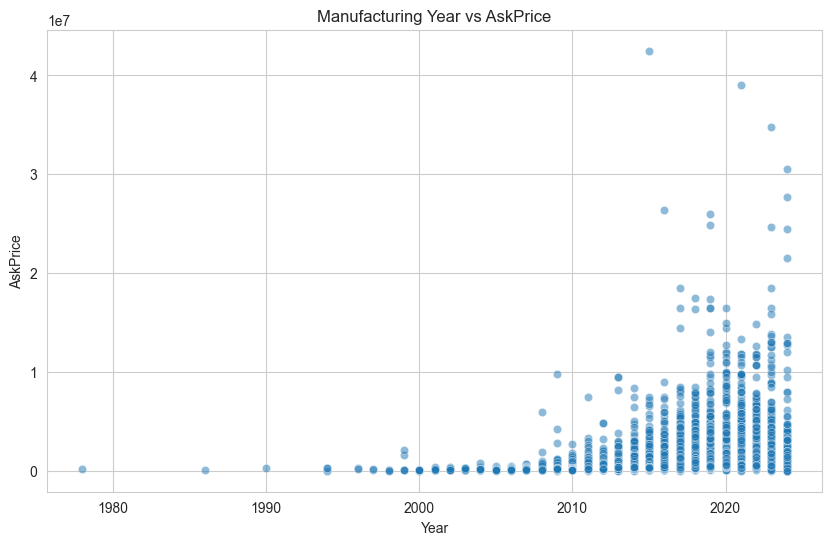

In [19]:
# Graph 7: Year vs AskPrice

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Year",
    y="AskPrice",
    alpha=0.5
)

plt.title("Manufacturing Year vs AskPrice")

plt.show()

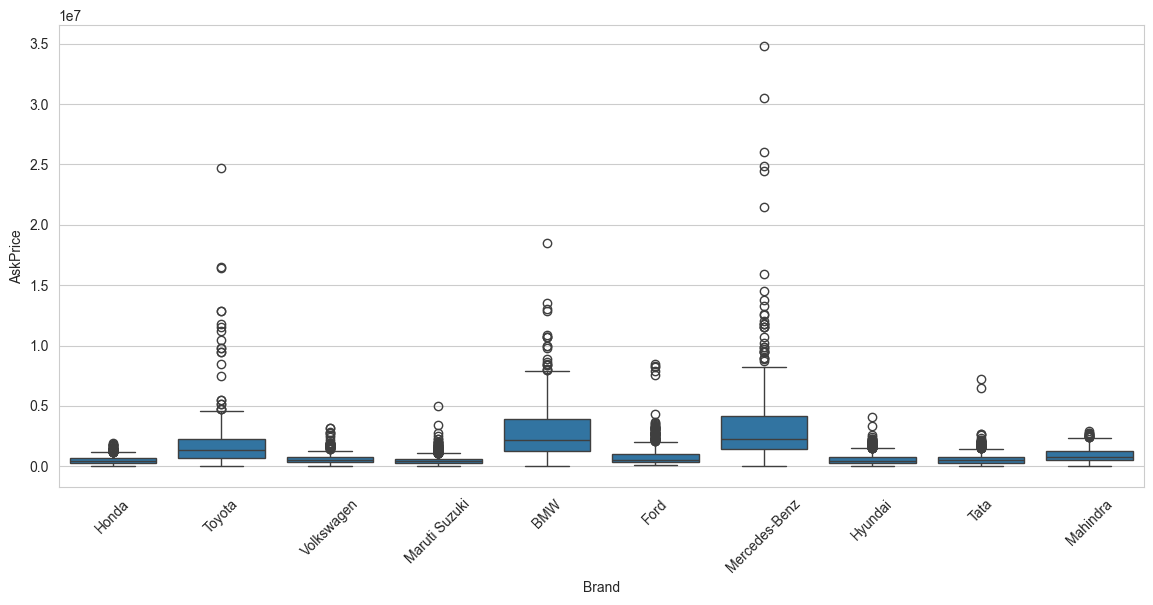

In [20]:
# Graph 9: Brand vs Price

top_brands = df["Brand"].value_counts().head(10).index

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df[df["Brand"].isin(top_brands)],
    x="Brand",
    y="AskPrice"
)

plt.xticks(rotation=45)

plt.show()

**Interpretation:**
- The feature-target analysis indicates that **Manufacturing Year** has a strong positive influence on resale price, as newer vehicles consistently tend to be priced higher than older ones due to lower depreciation, improved technology, and better overall condition. The increasing spread in prices for recent model years also reflects the presence of premium and luxury vehicles within newer listings. Furthermore, the brand-wise price distribution demonstrates that **Brand** is another key determinant of resale value. Luxury brands command substantially higher asking prices, while mass-market brands are concentrated within the affordable and mid-range price segments. These findings confirm that both **Manufacturing Year** and **Brand** carry significant predictive information for estimating used car prices.

**Business Recommendation:**
- Dealerships and online marketplaces should incorporate both **vehicle age** and **brand positioning** into their pricing strategies, as these factors strongly influence customer willingness to pay. Newer vehicles and premium brands can justify higher asking prices, whereas older vehicles and economy brands should be priced more competitively to remain attractive in the market. From a machine learning perspective, **Manufacturing Year** and **Brand** should be retained as high-impact features, as they capture important variations in depreciation patterns and brand-specific market value, thereby improving the accuracy of the price prediction model.

## Part 6 — Correlation Analysis

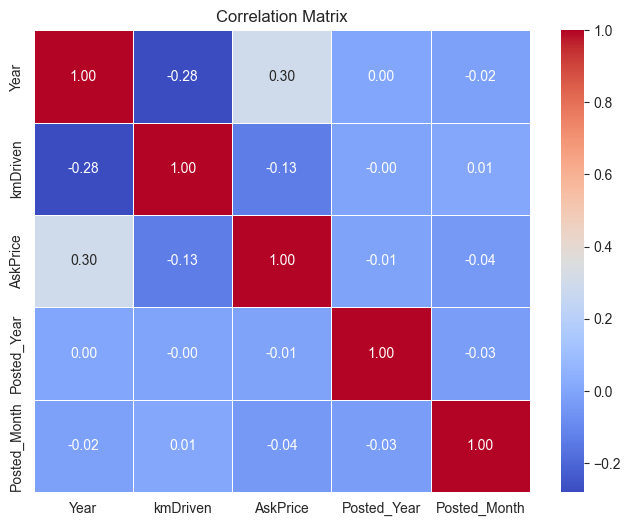

In [21]:
# Graph 10: Correlation Matrix

corr_df = df[
    [
        "Year",
        "kmDriven",
        "AskPrice",
        "Posted_Year",
        "Posted_Month"
    ]
]

# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

**Interpretation:**
- The correlation analysis indicates that **Manufacturing Year** is the strongest numerical predictor of resale price among the available features, suggesting that newer vehicles tend to command higher market values due to lower depreciation and improved features. **Kilometers Driven** shows a weak negative linear relationship with **AskPrice**, implying that vehicles with higher mileage generally sell for lower prices. However, the relatively low correlation suggests that resale value is influenced by multiple interacting factors such as brand, model, fuel type, and vehicle condition rather than mileage alone. The near-zero correlations for **Posted Year** and **Posted Month** indicate that the timing of a vehicle listing has little direct influence on its asking price.

**Business Recommendation:**
- Vehicle age should be considered a primary factor when estimating used car prices, as newer vehicles consistently retain higher resale values. Although mileage has a weaker individual correlation with price, it remains an important indicator of vehicle usage and should be evaluated alongside other characteristics during pricing decisions. From a machine learning perspective, **Manufacturing Year** and **Kilometers Driven** should be retained as key numerical features, while **Posted Year** and **Posted Month** may contribute limited predictive value and can be further assessed during feature selection and model evaluation.

## Part 7 — Outlier Analysis

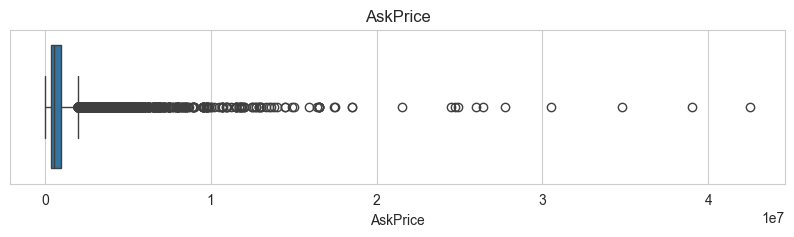

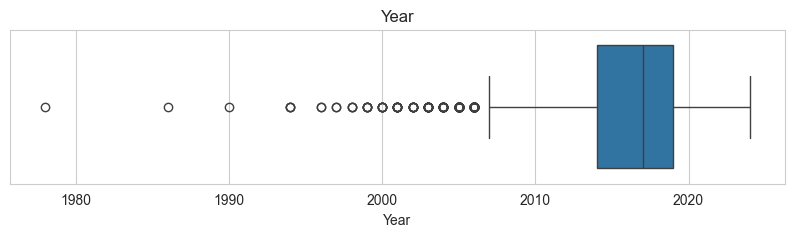

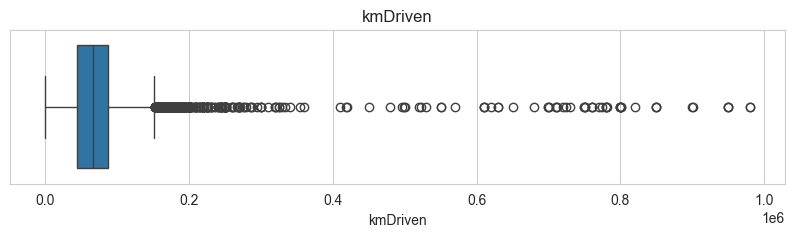

In [22]:
# Graph 11: Outlier Analysis

numerical_columns = [
    "AskPrice",
    "Year",
    "kmDriven"
]

for col in numerical_columns:

    plt.figure(figsize=(10,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [23]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers}")

AskPrice: 1391
Year: 194
kmDriven: 517


**Interpretation:**
The detected outliers largely reflect genuine characteristics of the used car market rather than data quality issues. High **AskPrice** values correspond to premium and luxury vehicles, while extremely **high Kilometers** Driven values represent heavily used vehicles with extensive service histories. Similarly, older manufacturing years represent classic or vintage vehicles that naturally occur in the marketplace. Since these observations capture real-world market variability, removing them could reduce the model's ability to learn price patterns across different vehicle segments.

**Business Recommendation:**
- Outliers should be retained because they represent legitimate market observations rather than erroneous records. Removing them could bias the model toward average-priced vehicles and reduce its ability to predict prices for premium, luxury, or high-mileage cars. From a machine learning perspective, instead of removing these observations, appropriate preprocessing techniques such as log transformation of the target variable, robust algorithms (e.g., tree-based models), and suitable evaluation metrics can help minimize the influence of extreme values while preserving valuable information.

## Part 8 - Missing Value Analysis

In [24]:
# Missing Value Analysis

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing = missing[missing["Missing Count"]>0]

missing

,Missing Count,Missing Percentage
kmDriven,87,0.62


**Interpretation:**
- The missing value analysis indicates that only the **kmDriven** feature contains missing values, with **87 missing observations (0.62%)**, while all other variables are complete. Since the proportion of missing data is less than 1% of the entire dataset, it is considered minimal and is unlikely to introduce significant bias into the analysis. Therefore, removing these records would unnecessarily reduce the available training data without providing any meaningful improvement in data quality.

**Business Recommendation:**
- From a machine learning perspective, the missing values in kmDriven should be retained and handled using a SimpleImputer within the preprocessing pipeline rather than being manually removed or filled during exploratory analysis. This approach ensures a consistent and reproducible preprocessing workflow, allowing the same imputation strategy to be automatically applied to both training data and unseen data during model deployment. Retaining these observations also preserves valuable information contained in the remaining features, leading to a more robust and reliable price prediction model.

## Part 9 - Feature Importance Expectations

In [33]:
# Expected Feature Importance 

feature_expectation = pd.DataFrame({
    "Feature": [
        "Brand",
        "Model",
        "Year",
        "kmDriven",
        "FuelType",
        "Transmission",
        "Owner",
        "Posted_Month",
        "Posted_Year"
    ],
    
    "Expected Predictive Power": [
        "Very High",
        "Very High",
        "Very High",
        "High",
        "Medium",
        "Medium",
        "Medium",
        "Low",
        "Very Low"
    ]
})

feature_expectation

,Feature,Expected Predictive Power
0,Brand,Very High
1,Model,Very High
2,Year,Very High
3,kmDriven,High
4,FuelType,Medium
5,Transmission,Medium
6,Owner,Medium
7,Posted_Month,Low
8,Posted_Year,Very Low


**Interpretation:**
- Based on the exploratory data analysis, **Brand, Model, Manufacturing Year**, and **Kilometers Driven** are expected to be the most influential predictors of used car prices because they directly capture vehicle quality, depreciation, and market demand. Features such as **Fuel Type, Transmission**, and **Ownership History** are also expected to contribute to price estimation, although their influence may be comparatively moderate. In contrast, **Posted Month** and **Posted Year** are anticipated to have limited predictive value because they exhibit minimal variation across the dataset. 

**Business Recommendation:**
- The expected feature importance analysis suggests that pricing strategies should primarily focus on vehicle-specific characteristics such as **Brand, Model, Manufacturing Year**, and **Kilometers Driven** as these factors are likely to drive the largest variations in resale value. During model development, all identified features will be retained initially, while their actual contribution will be validated using feature importance techniques after training the machine learning models.